In [1]:
import socket
import struct

# initialize variables
robotIP = "192.168.1.2"
PRIMARY_PORT = 30001
SECONDARY_PORT = 30002
REALTIME_PORT = 30003

# URScript command being sent to the robot
urscript_command = "movel(p[-0.55, -0.25, -0.15, 0, 0, 0], a=0.12, v=0.05)"
urscript_command = "get_actual_tcp_pose()"


# Creates new line
new_line = "\n"

def send_urscript_command(command: str):
    """
    This function takes the URScript command defined above, 
    connects to the robot server, and sends 
    the command to the specified port to be executed by the robot.

    Args:
        command (str): URScript command
        
    Returns: 
        None
    """
    try:
        # Create a socket connection with the robot IP and port number defined above
        s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        s.connect((robotIP, PRIMARY_PORT))

        # Appends new line to the URScript command (the command will not execute without this)
        command = command+new_line
        
        # Send the command
        s.sendall(command.encode('utf-8'))
        
        r= s.recv(1024)

        # Close the connection
        s.close()





    except Exception as e:
        print(f"An error occurred: {e}")

send_urscript_command(urscript_command)

In [2]:
import socket
import struct

def get_ur_pose():
    ip = "192.168.1.2"
    port = 30003  # 实时数据端口
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.connect((ip, port))
    data = s.recv(1108)  # 获取一个完整的状态包

    # 解析 TCP 位姿，从第444字节开始，连续6个 double（48 字节）
    pose = struct.unpack('!6d', data[444:444+48])
    s.close()
    return pose


pose = get_ur_pose()
print("TCP Pose:", pose)


TCP Pose: (-0.40792261376798244, -0.22463770057553256, 0.11301653836200617, -0.034697800263748434, -0.015770928144168885, -1.5342785015954665)


In [2]:
import numpy as np
import cv2
import glob

# 1. 准备棋盘格参数
CHECKERBOARD = (6,9) # 棋盘格内角点数量 (行, 列)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
desired_width = 2592 
desired_height = 1944

# 世界坐标系中的3D点
objp = np.zeros((CHECKERBOARD[0]*CHECKERBOARD[1],3), np.float32)
objp[:,:2] = np.mgrid[0:CHECKERBOARD[0],0:CHECKERBOARD[1]].T.reshape(-1,2)
# 如果你知道棋盘格方格的实际尺寸（例如 20mm），可以乘以这个值
objp = objp * 24 # 例如，每个方格 20mm

# 存储所有图像的3D点和2D点
objpoints = [] # 真实世界中的3D点
imgpoints = [] # 图像中的2D点

# 获取所有棋盘格图像的路径 (假设你把图片放在 'calibration_images/' 目录下)
images = glob.glob('C:/Users/admin/Desktop/huifeng/rlproject/src/calibration/img/*.jpg') # 或 .jpg

for fname in images:
    img = cv2.imread(fname)
    cv2.namedWindow('img', cv2.WINDOW_NORMAL) # 创建一个窗口来显示图像
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 查找棋盘格角点
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)

    # 如果找到角点，则添加对象点和图像点
    if ret == True:
        objpoints.append(objp)
        # 精细化角点位置
        corners2 = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
        imgpoints.append(corners2)

        # 绘制角点并显示 (可选)
        cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
        cv2.imshow('img', img)
        # if cv2.waitKey(0) == ord('q'):
        #     continue # 按 'q' 键跳过当前图像
    else:
        print(f"Warning: Could not find chessboard corners in {fname}")

cv2.destroyAllWindows()

# 2. 相机标定
print("Starting camera calibration...")
ret, K, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)


new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(K, dist_coeffs, (desired_width, desired_height), 1, (desired_width, desired_height))

np.savez('calibration_data.npz', ret=ret, K=K, dist_coeffs=dist_coeffs, rvecs=rvecs, tvecs=tvecs,new_camera_matrix=new_camera_matrix)
if ret:
    print("\nCalibration successful!")
    print("Camera Matrix (K):\n", K)
    print("\nDistortion Coefficients (dist_coeffs):\n", dist_coeffs)
  
    # 或者从摄像头获取一帧进行测试 (假设你已经连接了摄像头)
    cap = cv2.VideoCapture(0)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, desired_width) # 设置分辨率
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, desired_height) # 设置分辨率
    if not cap.isOpened():
        print("Error: Could not open camera for demonstration.")
        exit()
    ret_cam, img = cap.read()
    cap.release()
    if not ret_cam:
        print("Error: Could not read frame from camera for demonstration.")
        exit()


    # 方法二：使用 initUndistortRectifyMap 和 remap (更适合实时视频流)
    # mapx, mapy = cv2.initUndistortRectifyMap(K, dist_coeffs, None, new_camera_matrix, (w,h), 5) # 5 for CV_32FC1
    # remap_undistorted_img = cv2.remap(img, mapx, mapy, cv2.INTER_LINEAR)

    # cv2.imshow('Original Image', img)
    # cv2.imshow('Remapped Undistorted Image', remap_undistorted_img)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
 
else:
    print("Calibration failed!")

Starting camera calibration...

Calibration successful!
Camera Matrix (K):
 [[2.89891481e+03 0.00000000e+00 1.50873740e+03]
 [0.00000000e+00 2.88501287e+03 1.09150244e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion Coefficients (dist_coeffs):
 [[-0.52343938  0.46763081 -0.00135282  0.00314503 -0.34633763]]


In [5]:
import cv2
import numpy as np
from ultralytics import YOLO
desired_width = 2592 
desired_height = 1944
cap = cv2.VideoCapture(0)
cv2.namedWindow('Undistorted Frame', cv2.WINDOW_NORMAL)  # 创建一个窗口来显示矫正后的图像

if not cap.isOpened():
    print("Error: Could not open camera for demonstration.")
    exit()

clicked_x, clicked_y = -1, -1


# model = YOLO("../rl-project/runs/detect/train4/weights/best.pt")
object_points = [] # 用于存储世界坐标系中的点
img_points = []  # 用于存储图像坐标系中的点

calibration_data = np.load('camera_calibration\calibration_data.npz')
K = calibration_data['K']
dist_coeffs = calibration_data['dist_coeffs']

new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(K, dist_coeffs, (desired_width, desired_height), 0, (desired_width, desired_height))

def mouse_callback(event, x, y, flags, param):
    """
    鼠标事件发生时被调用的函数。
    """
    global clicked_x, clicked_y # 声明使用全局变量
    global object_points, img_points

    if event == cv2.EVENT_LBUTTONDOWN: # 检测鼠标左键按下事件
        clicked_x, clicked_y = x, y
        print(f"Clicked coordinates: ({clicked_x}, {clicked_y})")

        if len(object_points) < 8:
            p_x,p_y = get_ur_pose()[:2]
            # p_y -= 0.33
            object_points.append((p_x, p_y))
            img_points.append([clicked_x, clicked_y])
            


            print(f"Object points: {object_points}")
            print(f"Image points: {img_points}")


        

        # 计算单应性矩阵
        if len(object_points) >= 8:
            
            H, status = cv2.findHomography(np.array(object_points, dtype=np.float32), np.array(img_points, dtype=np.float32))
            print(f"Homography matrix: {H}")
            np.save('Homography_matrix.npy',H)
            print("Saved Homography matrix.")
            
        return

cap.set(cv2.CAP_PROP_FRAME_WIDTH, desired_width)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, desired_height)
i=26
while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame from camera for demonstration.")
        break
    
    # print(frame.shape)
    
    undistorted_frame = cv2.undistort(frame, K, dist_coeffs, None, new_camera_matrix)
    undistorted_frame = undistorted_frame[:,600:-400 ]
    undistorted_frame = cv2.rotate(undistorted_frame, cv2.ROTATE_90_COUNTERCLOCKWISE)
    # print(f"shape of undistorted_frame: {undistorted_frame.shape}")
    # results = model.predict(undistorted_frame, conf=0.5, save=False,imgsz=640)
    # for i, r in enumerate(results):
    #     boxes = r.boxes
    #     for box in boxes:
    #         # 提取边界框坐标
    #         x1, y1, x2, y2 = map(int, box.xyxy[0])
    #         # 计算中心点
    #         cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
    #         # 在图像上绘制边界框和中心点
    #         cv2.rectangle(undistorted_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    #         cv2.circle(undistorted_frame, (cx, cy), 5, (255, 0, 0), -1)
    #         cv2.putText(undistorted_frame, f'({cx}, {cy})', (cx + 10, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    #         print(f"Detected object at center: ({cx}, {cy})")



    # cv2.imshow('Original Frame', frame)
    # cv2.imshow('Undistorted Frame', cv2.resize(undistorted_frame, (desired_width, desired_height)))  # 缩放显示窗口大小
    cv2.imshow('Undistorted Frame', undistorted_frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    # if cv2.waitKey(100) & 0xFF == ord('w'):
    #     cv2.imwrite(f'img/img{i}.jpg', undistorted_frame)
    #     print(f'saved img/img{i}.jpg')
    #     i+=1

    cv2.setMouseCallback("Undistorted Frame", mouse_callback)
  
  
cap.release()
cv2.destroyAllWindows()

Clicked coordinates: (202, 793)
Object points: [(-0.5400963465042067, -0.4306552612946384)]
Image points: [[202, 793]]
Clicked coordinates: (536, 523)
Object points: [(-0.5400963465042067, -0.4306552612946384), (-0.3268251193692794, -0.43067051573659565)]
Image points: [[202, 793], [536, 523]]
Clicked coordinates: (254, 157)
Object points: [(-0.5400963465042067, -0.4306552612946384), (-0.3268251193692794, -0.43067051573659565), (-0.3268730102036658, -0.1954358166531549)]
Image points: [[202, 793], [536, 523], [254, 157]]
Clicked coordinates: (558, 870)
Object points: [(-0.5400963465042067, -0.4306552612946384), (-0.3268251193692794, -0.43067051573659565), (-0.3268730102036658, -0.1954358166531549), (-0.4477031845719876, -0.5582778231055769)]
Image points: [[202, 793], [536, 523], [254, 157], [558, 870]]
Clicked coordinates: (1012, 439)
Object points: [(-0.5400963465042067, -0.4306552612946384), (-0.3268251193692794, -0.43067051573659565), (-0.3268730102036658, -0.1954358166531549), (-0

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2546: error: (-27:Null pointer) NULL window: 'Undistorted Frame' in function 'cvSetMouseCallback'


In [6]:
import numpy as np
import cv2
import time




desired_width = 2592 
desired_height = 1944





H = np.load(r'C:\Users\admin\Desktop\huifeng\RL\rlproject\src\camera_calibration\Homography_matrix.npy')
print(H)
calibration_data = np.load(r'C:\Users\admin\Desktop\huifeng\RL\rlproject\src\camera_calibration\calibration_data.npz')
K = calibration_data['K']
dist_coeffs = calibration_data['dist_coeffs']

new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(K, dist_coeffs, (desired_width, desired_height), 0, (desired_width, desired_height))

cap = cv2.VideoCapture(0)
cv2.namedWindow('Undistorted Frame', cv2.WINDOW_NORMAL)  # 创建一个窗口来显示矫正后的图像
# cv2.namedWindow('Original Frame', cv2.WINDOW_NORMAL)  # 创建一个窗口来显示原始图像
if not cap.isOpened():
    print("Error: Could not open camera for demonstration.")
    exit()

clicked_x, clicked_y = -1, -1

object_points = [] # 用于存储世界坐标系中的点
img_points = []  # 用于存储图像坐标系中的点



def mouse_callback(event, x, y, flags, param):
    """
    鼠标事件发生时被调用的函数。
    """

    global clicked_x, clicked_y # 声明使用全局变量
    global object_points,tcp_points, img_points
    if event == cv2.EVENT_LBUTTONDOWN: # 检测鼠标左键按下事件

        clicked_x, clicked_y = x, y
        print(f"Clicked at ({clicked_x}, {clicked_y})")
        x_curr, y_curr,z,rx,ry,rz = get_ur_pose()[:6]

        point_pixel = np.array([[clicked_x], [clicked_y], [1]], dtype=np.float32)
        point_world_homo = np.linalg.inv(H) @ point_pixel
        x_obj = point_world_homo[0] / point_world_homo[2]
        y_obj = point_world_homo[1] / point_world_homo[2]

        r = 0.015
        x_tcp = x_obj + r*(x_obj - x_curr)/np.sqrt((x_obj - x_curr)**2 + (y_obj - y_curr)**2)
        y_tcp = y_obj + r*(y_obj - y_curr)/np.sqrt((x_obj - x_curr)**2 + (y_obj - y_curr)**2)

        urscript_command = f'movel(p[{x_tcp[0]},{y_tcp[0]},{z},{rx},{ry},{rz}],a = 0.12,v = 0.3)'
        # urscript_command = f'movel(p[{x_obj[0]},{y_obj[0]},{z},0.0,0.0,0.0],a = 0.12,v = 0.05)'

        # tcp_points.append([x_tcp, y_tcp, z])
        print(urscript_command)
        send_urscript_command(urscript_command)

        print(f"Object points: {object_points}")
        print(f"Image points: {img_points}")

        return clicked_x, clicked_y

cap.set(cv2.CAP_PROP_FRAME_WIDTH, desired_width)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, desired_height)

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame from camera for demonstration.")
        break
    # 使用 cv2.undistort 对每一帧进行畸变矫正
    # undistorted_frame = frame
    undistorted_frame = cv2.undistort(frame, K, dist_coeffs, None, new_camera_matrix)
    undistorted_frame = undistorted_frame[:,600:-400 ]
    undistorted_frame = cv2.rotate(undistorted_frame, cv2.ROTATE_90_COUNTERCLOCKWISE)


    cv2.circle(undistorted_frame, (clicked_x, clicked_y), 15, (255, 0, 255), -1)  # 在中心点画一个绿色圆圈
    # cv2.imshow('Undistorted Frame', cv2.resize(undistorted_frame, (desired_width, desired_height)))
    cv2.imshow('Undistorted Frame',undistorted_frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    


    cv2.setMouseCallback("Undistorted Frame", mouse_callback)

cap.release()
cv2.destroyAllWindows()


[[     1468.6     -1125.7      489.18]
 [    -1145.7     -1249.8     -463.01]
 [    0.07428     0.20645           1]]
Clicked at (796, 752)
movel(p[-0.3248045639468353,-0.574794006256473,0.11296861318528342,-0.03437228479336796,-0.01580525288124325,-1.534546980341932],a = 0.12,v = 0.3)
Object points: []
Image points: []
Clicked at (607, 519)
movel(p[-0.3116883104568611,-0.435511788320109,0.11296148616320824,-0.034396697050528446,-0.015770676458952897,-1.5345143272709065],a = 0.12,v = 0.3)
Object points: []
Image points: []


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2546: error: (-27:Null pointer) NULL window: 'Undistorted Frame' in function 'cvSetMouseCallback'


In [5]:
import gymnasium as gym
from gymnasium.spaces import Box, Discrete,Tuple
import numpy as np
import pygame

# Define colors
WHITE = (255, 255, 255)
RED = (255, 0, 0)
GREEN = (0, 255, 0)
BLUE = (0, 0, 255)  # Color for the trajectory

class CustomEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 60}

    def __init__(self,render_mode=None):
        super().__init__()
        self.grid_size = 10
        self.pause = False
        self.domain_randomization = False
        self.render_mode = render_mode

        # Define two separate thresholds for obstacle handling
        self.distance_threshold_penalty = 3  # Penalty zone threshold (larger value)
        self.distance_threshold_collision = 1.5  # Collision threshold (smaller value)
        self.penalty_factor = 5  # Penalty scaling factor
        self.distance_reward_factor = 10
        self.smooth_action_penalty = 1
        self.steps = 0
        self.margin = 0.1
        self.stride_hand = 0.8
        self.pre_distance = 0  # Previous distance to goal, used for reward shaping
        self.current_distance = 0  # Current distance to goal, used for reward shaping
        self.max_steps = 50  # Set a maximum number of steps to prevent infinite loops
        # Action space (dx, dy)
        self.action_space = Box(low=-1, high=1, shape=(2,), dtype=np.float32)
        # Observation space (robot_x, robot_y, goal_x, goal_y)
        self.observation_shape = 2+2+2+1+1  # Robot position, hand position, velocity_hand,radius_hand, and distance to hand
        self.observation_space = Box(low=0, high=np.array([self.grid_size,self.grid_size, self.grid_size, self.grid_size,1,1 , (2**0.5)*self.grid_size,0.5*self.grid_size]), 
                                    shape=(self.observation_shape,), dtype=np.float32)

        self.random = True
        # For rendering
        self.window = None
        self.clock = None
        self.cell_size = 50 # Pixels per grid unit
        self.trajectory_points = [] # New: List to store past robot positions

    def _get_obs(self):
        
        return np.concatenate(([self.robot_position]+ [self.hand_position]+[self.last_action]+
                               [np.array([self.current_distance])]+
                               [np.array([min(self.robot_position[0],
                                              self.robot_position[1],
                                              self.grid_size-self.robot_position[0],
                                              self.grid_size-self.robot_position[1]) ])]))

    def _get_info(self):
        return {
            "distance_to_hand": self.current_distance,
            "robot_position": self.robot_position,
            "hand_position": self.hand_position,
        }

    def reset(self, seed=None, options=None):

        super().reset()
        self.stride_hand = 0.8* np.random.uniform(0.8, 1.2)  # Randomize stride length
        self.distance_threshold_collision *= np.random.uniform(0.8, 1.2)  # Randomize collision threshold
        self.distance_threshold_penalty *= np.random.uniform(0.8, 1.2)  # Randomize penalty threshold
        self.noise_obs_sigma = np.random.uniform(0, 0.1)  # Add some noise to observation to make it more realistic
        self.noise_action_sigma = np.random.uniform(0,0.1)  # Add some noise to action to make it more realistic
        self.robot_position = np.random.uniform(self.margin, self.grid_size-self.margin, size=2)

        self.hand_position = np.random.uniform(self.margin, self.grid_size-self.margin, size=2)
        # self.hand_position = np.clip(self.hand_position, self.margin, self.grid_size-self.margin)  # Ensure hand stays within grid bounds
        
        self.current_distance = np.linalg.norm(self.robot_position - self.hand_position)
        self.current_distance = self.current_distance
        self.last_action = np.zeros(2)
        self.steps = 0
        self.trajectory_points = [self.robot_position.copy()] # New: Reset trajectory and add initial position
        
        return self._get_obs(), self._get_info()

    def _reward(self,action):
        terminated = False
        truncated = False
        reward = 0  # Initialize reward
        done_reason = None  # Initialize done reason

        # action regulation penalty

        reward -= 0.5 * np.sum(np.square(action))  # Penalty for large actions

        if np.any(self.robot_position <= self.margin) or np.any(self.grid_size-self.robot_position <=self.margin):
            reward -= 400
            terminated = True  # Truncate if robot goes out of bounds
            done_reason = "out of bounds"

        # self.robot_position = np.clip(self.robot_position, self.margin, self.grid_size-self.margin)  # Ensure robot stays within grid bounds
        # boundary penalty

        reward -= self.smooth_action_penalty*np.linalg.norm(action-self.last_action)  # Penalty for smooth action
        self.last_action = action
        # Auxiliary Rewards -  distance to hand
        self.current_distance = np.linalg.norm(self.robot_position - self.hand_position)
        reward += (self.current_distance-self.pre_distance)*self.distance_reward_factor  # Reward shaping based on distance change
        self.pre_distance = self.current_distance

        # Obstacle handling with two thresholds
        if self.current_distance < self.distance_threshold_collision:
            reward -= 100
            terminated = True  # Terminate if too close to obstacles
            done_reason = "collision with obstacle"
        elif self.current_distance < self.distance_threshold_penalty:
            reward -= self.penalty_factor * (self.distance_threshold_penalty - self.current_distance)  # Penalty for being too close to obstacles

        
        
        reward+=  4  # Small reward for each step taken to encourage exploration
        if self.steps >= self.max_steps:
            reward += 50
            truncated = True  # Truncate if max steps reached
        return reward,terminated,truncated,done_reason
        

    def step(self, action):
        if self.random:
            action+=np.random.normal(0,self.noise_action_sigma,size=self.action_space.shape)  # Add some noise to action to make it more realistic

        rand = np.random.rand()
        if rand < 0.1:
            move_hand = np.random.uniform(-1, 1, size=2)  # Randomly move the hand position slightly
        # elif rand < 0.2:
            # move_hand = np.random.uniform(-3, 3, size=2)  # Randomly move the hand position
        else:
        
            # move towards the robot position
            dir_vector = self.robot_position - self.hand_position
            if np.linalg.norm(dir_vector) > 0:
                dir_vector /= np.linalg.norm(dir_vector)
            move_hand = dir_vector * self.stride_hand  # Move hand towards robot position
        self.hand_position += move_hand  # Update hand position
        self.hand_position = np.clip(self.hand_position, self.margin, self.grid_size-self.margin)  # Ensure hand stays within grid bounds
        stride = 1  # Base stride length
        self.robot_position += action * stride  # Scale the action to control speed
        self.trajectory_points.append(self.robot_position.copy()) # New: Add current position to trajectory
        reward,terminated,truncated,done_reason = self._reward(action)
        info = self._get_info()
        info['done_reason'] = done_reason
        observation = self._get_obs()
        self.steps += 1
        if self.random:
            observation += np.random.normal(0, self.noise_obs_sigma, size=self.observation_shape)  # Add some noise to observation to make it more realistic

        return observation, reward, terminated, truncated, info

    def render(self, mode="human"):
 
        pygame.display.init()
        self.window = pygame.display.set_mode(
                (int(self.grid_size * self.cell_size), int(self.grid_size * self.cell_size))
            )
        pygame.display.set_caption("CustomEnv")
        if self.clock is None:
            self.clock = pygame.time.Clock()
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                import sys
                sys.exit() # Exit the program

            elif event.type == pygame.MOUSEBUTTONDOWN:
                mouse_x, mouse_y = event.pos
                self.hand_position = np.array([mouse_x/self.cell_size, mouse_y/self.cell_size])

            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_SPACE:  # 空格键切换暂停
                    self.pause = not self.pause


        canvas = pygame.Surface((self.grid_size * self.cell_size, self.grid_size * self.cell_size))
        canvas.fill(WHITE)
        virus_image = pygame.image.load("hand.png").convert_alpha()  # Load an image if needed, but not used here
        robot_image = pygame.transform.scale(virus_image, (int(self.cell_size * 2), int(self.cell_size * 2)))  # Scale the image
        # New: Draw the trajectory
        if len(self.trajectory_points) > 1:
            scaled_points = []
            for point in self.trajectory_points:
                scaled_points.append((int(point[0] * self.cell_size), int(point[1] * self.cell_size)))
            
            # Draw lines between consecutive points
            pygame.draw.lines(canvas, BLUE, False, scaled_points, 2) # Blue line, not closed, 2 pixels wide
            
            # Optionally, draw small circles at each point to emphasize
            for point_coord in scaled_points:
                pygame.draw.circle(canvas, BLUE, point_coord, 3) # Small blue circles

        # Draw robot
        pygame.draw.circle(
            canvas,
            RED,
            (int(self.robot_position[0] * self.cell_size), int(self.robot_position[1] * self.cell_size)),
            int(self.cell_size * 0.2)
        )
        # Draw obstacles

        canvas.blit(robot_image, (int((self.hand_position[0]-1) * self.cell_size), int((self.hand_position[1]-1) * self.cell_size+1)))
        pygame.draw.circle(canvas,
                            GREEN, 
                            (int((self.hand_position[0]) * self.cell_size), 
                            int((self.hand_position[1]) * self.cell_size+1)), 
        int(self.cell_size * 0.2)
        )

        self.window.blit(canvas, canvas.get_rect())
        pygame.event.pump()
        pygame.display.flip()
        self.clock.tick(self.metadata["render_fps"])
        time.sleep(0.5)

    def close(self):
        pygame.display.quit()
        pygame.quit()





In [29]:
def render_environment(robot_position, hand_position, trajectory_points, grid_size=10, cell_size=50):
    WHITE = (255, 255, 255)
    RED = (255, 0, 0)
    GREEN = (0, 255, 0)
    BLUE = (0, 0, 255)

    window = pygame.display.set_mode((grid_size * cell_size, grid_size * cell_size))
    canvas = pygame.Surface((grid_size * cell_size, grid_size * cell_size))
    canvas.fill(WHITE)
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            pygame.quit()
            import sys
            sys.exit() # Exit the program

        elif event.type == pygame.MOUSEBUTTONDOWN:
            mouse_x, mouse_y = event.pos
            hand_position = np.array([mouse_x/cell_size, mouse_y/cell_size])

    if len(trajectory_points) > 1:
        scaled_points = [(int(point[0] * cell_size), int(point[1] * cell_size)) for point in trajectory_points]
        pygame.draw.lines(canvas, BLUE, False, scaled_points, 2)
        for point_coord in scaled_points:
            pygame.draw.circle(canvas, BLUE, point_coord, 3)
    virus_image = pygame.image.load("hand.png").convert_alpha()  # Load an image if needed, but not used here
    robot_image = pygame.transform.scale(virus_image, (int(cell_size * 2), int(cell_size * 2)))  # Scale the image
    pygame.draw.circle(canvas, RED, (int(robot_position[0] * cell_size), int(robot_position[1] * cell_size)), int(cell_size * 0.2))
    pygame.draw.circle(canvas, GREEN, (int(hand_position[0] * cell_size), int(hand_position[1] * cell_size)), int(cell_size * 0.2))
    canvas.blit(robot_image, (int((hand_position[0]-1) * cell_size), int((hand_position[1]-1) * cell_size)))

    window.blit(canvas, canvas.get_rect())
    pygame.display.flip()

    return hand_position

In [ ]:
from stable_baselines3 import PPO,SAC
import numpy as np
import cv2
import time
import mediapipe as mp
from custom_env import CustomEnv
import pygame




env = CustomEnv()
env.random = False
model = SAC.load(
    "logs/best_model_sac7/best_model.zip",
    env=env,
    # custom_objects={
    #     "observation_space": env.observation_space,
    #     "action_space": env.action_space
    # }
)




mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    max_num_hands=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)



desired_width = 2592 
desired_height = 1944

H = np.load('Homography_matrix.npy')
print(H)
calibration_data = np.load('calibration_data.npz')
K = calibration_data['K']
dist_coeffs = calibration_data['dist_coeffs']

new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(K, dist_coeffs, (desired_width, desired_height), 0, (desired_width, desired_height))





cap = cv2.VideoCapture(0)
cv2.namedWindow('Frame', cv2.WINDOW_NORMAL)  # 创建一个窗口来显示矫正后的图像
# cv2.namedWindow('Original Frame', cv2.WINDOW_NORMAL)  # 创建一个窗口来显示原始图像
if not cap.isOpened():
    print("Error: Could not open camera for demonstration.")
    exit()

clicked_x, clicked_y = 1000, 1000
position_hand_env = [0,0]
object_points = [] # 用于存储世界坐标系中的点
img_points = []  # 用于存储图像坐标系中的点



def mouse_callback(event, x, y, flags, param):
    """
    鼠标事件发生时被调用的函数。
    """

    global clicked_x, clicked_y # 声明使用全局变量
    # global position_hand_env
    if event == cv2.EVENT_LBUTTONDOWN: # 检测鼠标左键按下事件
        clicked_x, clicked_y = x, y
        # print(np.linalg.inv(H) @ np.array([x, y, 1],dtype=np.float32))
        # position_hand_env = np.linalg.inv(H) @ np.array([x, y, 1],dtype=np.float32)[:2]
        # print(np.linalg.inv(H) @ np.array([x, y, 1],dtype=np.float32))

        # position_hand_env = 

        return clicked_x, clicked_y

cap.set(cv2.CAP_PROP_FRAME_WIDTH, desired_width)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, desired_height)

frame_count = 0
fps = 0.0
fps_interval = 1.0
fps_ts = time.time()

last_trigger_time = time.time()
interval = 0.5
trajectory = []
last_action = [0,0]

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame from camera for demonstration.")
        break
    # 使用 cv2.undistort 对每一帧进行畸变矫正
    undistorted_frame = cv2.undistort(frame, K, dist_coeffs, None, new_camera_matrix)
    undistorted_frame = undistorted_frame[:1300, :1400]
    h , w = undistorted_frame.shape[:2]


    # cv2.circle(undistorted_frame, (clicked_x, clicked_y), 15, (255, 0, 255), -1)  # 在中心点画一个绿色圆圈
    # cv2.imshow('Undistorted Frame', cv2.resize(undistorted_frame, (desired_width, desired_height)))
    
    rgb = cv2.cvtColor(undistorted_frame, cv2.COLOR_BGR2RGB)
    
    results = hands.process(rgb)

    if results.multi_hand_landmarks:
        for lm in results.multi_hand_landmarks:
            # 绘制关键点
            # mp_draw.draw_landmarks(undistorted_frame, lm, mp_hands.HAND_CONNECTIONS)

            # 获取像素坐标列表
            pts = [(int(pt.x * w), int(pt.y * h)) for pt in lm.landmark]
            # 多数情况下，手掌中心使用 landmarks 0, center
            # 这里使用所有21个点平均作为中心
            cx = int(np.mean([p[0] for p in pts]))
            cy = int(np.mean([p[1] for p in pts]))

            # 可视化中心点
            cv2.circle(undistorted_frame, (cx, cy), 8, (0, 0, 255), -1)

            position_hand_env = cx*10/w, cy*10/h
            # print(f"Hand center: ({cx}, {cy})")

        













    # position_hand_env = clicked_x*10/w, clicked_y*10/h
    
    key = cv2.waitKey(1) 
    if key== ord('q'):
        break
    
    now = time.time()
    
    if now - last_trigger_time > interval:
        
        *position_robot_world,z,rx,ry,rz = get_ur_pose()
        # print(position_robot_world)
        position_robot_pixel = H @ np.array([position_robot_world[0], position_robot_world[1], 1],dtype=np.float32)
        position_robot_pixel /= position_robot_pixel[2]

        # print(position_robot_pixel)

        position_robot_env = position_robot_pixel[0]*10 /w , position_robot_pixel[1]*10 / h


        distance_to_object = np.linalg.norm(np.array(position_robot_env) - np.array(position_hand_env))


        robot = np.array([position_robot_env],dtype=np.float32)

        hand = np.array([position_hand_env],dtype=np.float32)

        distance = np.array([distance_to_object],dtype=np.float32)
        boundary = np.array([min(position_robot_env[0],position_robot_env[1],10-position_robot_env[0],10-position_robot_env[1])],dtype=np.float32)
        last_action = np.array([last_action],dtype=np.float32)
        obs = np.concatenate((robot.flatten(),hand.flatten(),last_action.flatten(),distance.flatten(),boundary.flatten()))
        
        action, _states = model.predict(obs, deterministic=True)
        last_action = action    
        print(f"obs:{obs}\n action:{action}")
        action_pixel = action * np.array([desired_width/10,desired_height/10])
        
        # print(action_pixel)

        position_robot_pixel += np.array([action_pixel[0],action_pixel[1],1])
        # print(position_robot_pixel)
        position_robot_world = np.linalg.inv(H) @ np.array([position_robot_pixel[0], position_robot_pixel[1], 1],dtype=np.float32)
        position_robot_world /= position_robot_world[2]
        # print(position_robot_world)
        # print(action_pixel,position_robot_pixel,position_robot_world)

        urscript_command = f'movel(p[{position_robot_world[0]},{position_robot_world[1]},{z},{rx},{ry},{rz}],a = 0.5,v = 0.2,r = 0.005)'

        send_urscript_command(urscript_command)

        last_trigger_time = now
        trajectory.append(position_robot_env)
        render_environment(obs[:2],obs[2:4],trajectory)
    
    cv2.setMouseCallback("Frame", mouse_callback)
    frame_count += 1
    if (time.time() - fps_ts) > fps_interval:
        fps = frame_count / (time.time() - fps_ts)
        frame_count = 0
        fps_ts = time.time()

    cv2.putText(undistorted_frame, f"FPS: {fps:.2f}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.imshow('Frame', undistorted_frame)
cap.release()
cv2.destroyAllWindows()



Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
[[ 1.91426255e+03  2.43381742e+03  4.02027436e+03]
 [ 2.45894234e+03 -1.72990260e+03  4.63628370e+02]
 [ 5.36984560e-02  1.11159634e-01  1.00000000e+00]]
obs:[3.135159  2.4586475 0.        0.        0.        0.        3.98424
 2.4586475]
 action:[ 0.9506506  -0.17751813]
obs:[ 3.136826    2.4580717   0.          0.          0.9506506  -0.17751813
  3.9851968   2.4580717 ]
 action:[ 0.98841095 -0.01615679]
obs:[ 4.226597    2.305936    0.          0.          0.98841095 -0.01615679
  4.8147135   2.305936  ]
 action:[0.9780555  0.13770902]
obs:[4.8628807  2.4093645  0.         0.         0.9780555  0.13770902
 5.427029   2.4093645 ]
 action:[0.9682795 0.1527152]
obs:[5.902071  2.5047412 0.        0.        0.9682795 0.1527152 6.4115653
 2.5047412]
 action:[0.95753384 0.06542766]
obs:[6.557138   2.616126   1.5642858  6.876923   0.95753384 0.06542766
 6.563761   2.616126  ]
 action:[ 0.4873706 -0.1003105]
obs:[ 7

SystemExit: 

: 

In [7]:
from stable_baselines3 import PPO,SAC
import numpy as np
import cv2
import time
import mediapipe as mp
from custom_env import CustomEnv
import pygame






mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    max_num_hands=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)



desired_width = 2592 
desired_height = 1944

H = np.load('Homography_matrix.npy')
print(H)
calibration_data = np.load('calibration_data.npz')
K = calibration_data['K']
dist_coeffs = calibration_data['dist_coeffs']

new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(K, dist_coeffs, (desired_width, desired_height), 0, (desired_width, desired_height))





cap = cv2.VideoCapture(0)
cv2.namedWindow('Undistorted Frame', cv2.WINDOW_NORMAL)  # 创建一个窗口来显示矫正后的图像
# cv2.namedWindow('Original Frame', cv2.WINDOW_NORMAL)  # 创建一个窗口来显示原始图像
if not cap.isOpened():
    print("Error: Could not open camera for demonstration.")
    exit()

clicked_x, clicked_y = 1000, 1000
position_hand_env = [0,0]
object_points = [] # 用于存储世界坐标系中的点
img_points = []  # 用于存储图像坐标系中的点




cap.set(cv2.CAP_PROP_FRAME_WIDTH, desired_width)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, desired_height)

frame_count = 0
fps = 0.0
fps_interval = 1.0
fps_ts = time.time()

last_trigger_time = time.time()
interval = 0.5
trajectory = []
last_action = [0,0]

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame from camera for demonstration.")
        break
    # 使用 cv2.undistort 对每一帧进行畸变矫正
    undistorted_frame = cv2.undistort(frame, K, dist_coeffs, None, new_camera_matrix)
    # undistorted_frame = undistorted_frame[:1250, 135:1300]
    h , w = undistorted_frame.shape[:2]


    # cv2.circle(undistorted_frame, (clicked_x, clicked_y), 15, (255, 0, 255), -1)  # 在中心点画一个绿色圆圈
    # cv2.imshow('Undistorted Frame', cv2.resize(undistorted_frame, (desired_width, desired_height)))
    
    rgb = cv2.cvtColor(undistorted_frame, cv2.COLOR_BGR2RGB)
    mp_drawing = mp.solutions.drawing_utils
    results = hands.process(rgb)
    landmark_style = mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=8)
    connection_style = mp_drawing.DrawingSpec(color=(255, 0, 0), thickness=2)
    if results.multi_hand_landmarks:
        for lm in results.multi_hand_landmarks:
            # 绘制关键点
            mp_draw.draw_landmarks(undistorted_frame, lm, mp_hands.HAND_CONNECTIONS, landmark_style, connection_style)

            # 获取像素坐标列表
            pts = [(int(pt.x * w), int(pt.y * h)) for pt in lm.landmark]
            # 多数情况下，手掌中心使用 landmarks 0, center
            # 这里使用所有21个点平均作为中心
            cx = int(np.mean([p[0] for p in pts]))
            cy = int(np.mean([p[1] for p in pts]))

            # 可视化中心点
            # cv2.circle(undistorted_frame, (cx, cy), 8, (0, 0, 255), -1)

            position_hand_env = cx*10/w, cy*10/h
            # print(f"Hand center: ({cx}, {cy})")

        













    
    
    key = cv2.waitKey(1) 
    if key== ord('q'):
        break

    # cv2.putText(undistorted_frame, f"FPS: {fps:.2f}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.imshow('Undistorted Frame', undistorted_frame)
cap.release()
cv2.destroyAllWindows()



[[ 3.19749972e+03  1.05838379e+03  4.38403597e+03]
 [ 1.10302954e+03 -3.17822560e+03  7.70454812e+02]
 [ 1.38408357e-02  5.48469860e-02  1.00000000e+00]]


In [20]:
from stable_baselines3 import PPO
import numpy as np
import cv2
import time
import mediapipe as mp



cap = cv2.VideoCapture(0)
cv2.namedWindow('Undistorted Frame', cv2.WINDOW_NORMAL)  # 创建一个窗口来显示矫正后的图像
# cv2.namedWindow('Original Frame', cv2.WINDOW_NORMAL)  # 创建一个窗口来显示原始图像
if not cap.isOpened():
    print("Error: Could not open camera for demonstration.")
    exit()

clicked_x, clicked_y = 1000, 1000
position_hand_env = [0,0]
object_points = [] # 用于存储世界坐标系中的点
img_points = []  # 用于存储图像坐标系中的点



def mouse_callback(event, x, y, flags, param):
    """
    鼠标事件发生时被调用的函数。
    """

    global clicked_x, clicked_y # 声明使用全局变量
    # global position_hand_env
    if event == cv2.EVENT_LBUTTONDOWN: # 检测鼠标左键按下事件
        clicked_x, clicked_y = x, y
        # print(np.linalg.inv(H) @ np.array([x, y, 1],dtype=np.float32))
        # position_hand_env = np.linalg.inv(H) @ np.array([x, y, 1],dtype=np.float32)[:2]
        # print(np.linalg.inv(H) @ np.array([x, y, 1],dtype=np.float32))

        # position_hand_env = 

        return clicked_x, clicked_y

# cap.set(cv2.CAP_PROP_FPS, 60)
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
# cap.set(cv2.CAP_PROP_FPS, 30)

frame_count = 0
fps = 0.0
fps_interval = 1.0
fps_ts = time.time()
last_trigger_time = time.time()
interval = 1
while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame from camera for demonstration.")
        break
    # 使用 cv2.undistort 对每一帧进行畸变矫正
    # undistorted_frame = cv2.undistort(frame, K, dist_coeffs, None, new_camera_matrix)
    # h , w = undistorted_frame.shape[:2]


    # cv2.circle(undistorted_frame, (clicked_x, clicked_y), 15, (255, 0, 255), -1)  # 在中心点画一个绿色圆圈
    # cv2.imshow('Undistorted Frame', cv2.resize(undistorted_frame, (desired_width, desired_height)))

    # rgb = cv2.cvtColor(undistorted_frame, cv2.COLOR_BGR2RGB)
    # results = hands.process(rgb)

    # if results.multi_hand_landmarks:
    #     for lm in results.multi_hand_landmarks:
    #         # 绘制关键点
    #         # mp_draw.draw_landmarks(undistorted_frame, lm, mp_hands.HAND_CONNECTIONS)

    #         # 获取像素坐标列表
    #         pts = [(int(pt.x * w), int(pt.y * h)) for pt in lm.landmark]
    #         # 多数情况下，手掌中心使用 landmarks 0, center
    #         # 这里使用所有21个点平均作为中心
    #         cx = int(np.mean([p[0] for p in pts]))
    #         cy = int(np.mean([p[1] for p in pts]))

    #         # 可视化中心点
    #         cv2.circle(undistorted_frame, (cx, cy), 8, (0, 0, 255), -1)

    #         position_hand_env = cx*10/w, cy*10/h
    #         # print(f"Hand center: ({cx}, {cy})")



    cv2.putText(frame, f"FPS: {fps:.2f}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.imshow('Undistorted Frame', frame)
cap.release()
cv2.destroyAllWindows()



FPS: 9.73
FPS: 18.28
FPS: 18.83
FPS: 18.52
FPS: 18.88
FPS: 18.61
FPS: 18.87
FPS: 18.87
FPS: 18.45
FPS: 18.40
FPS: 18.72
FPS: 18.52
FPS: 18.16
FPS: 18.82
FPS: 18.78
FPS: 18.82
FPS: 17.81
FPS: 18.84
FPS: 18.83
FPS: 18.78
FPS: 16.86
FPS: 18.84
FPS: 16.47
FPS: 16.80
FPS: 18.11
FPS: 18.81
FPS: 18.87
FPS: 18.65
FPS: 18.76
FPS: 18.81
FPS: 18.20
FPS: 18.49
FPS: 18.29
FPS: 17.86
FPS: 18.66
FPS: 18.80
FPS: 18.78
FPS: 18.76
FPS: 18.79
FPS: 18.83
FPS: 18.78
FPS: 18.13
FPS: 17.20
FPS: 18.20
FPS: 18.76
FPS: 18.85
FPS: 18.47
FPS: 18.90
FPS: 18.87
FPS: 18.85
FPS: 18.82
FPS: 18.62
FPS: 18.87
FPS: 17.86
FPS: 18.81
FPS: 18.82
FPS: 18.86
FPS: 18.87
FPS: 18.91
FPS: 18.85
FPS: 18.86
FPS: 18.79
FPS: 18.30
FPS: 18.83
FPS: 18.39
FPS: 18.75
FPS: 18.92
FPS: 18.34
FPS: 18.33
FPS: 18.65
FPS: 18.79
FPS: 17.22
FPS: 18.89
FPS: 18.83
FPS: 18.60
FPS: 18.85
FPS: 18.64
FPS: 18.78
FPS: 18.46
FPS: 18.00
FPS: 18.77
FPS: 18.75
FPS: 18.83
FPS: 18.96
FPS: 18.91
FPS: 17.13
FPS: 18.58
FPS: 17.21
FPS: 16.75
FPS: 18.82
FPS: 17.53


KeyboardInterrupt: 

开始进行波峰波谷识别...
信号已使用高斯滤波进行平滑，sigma=15
识别到 20 个波峰。
识别到 0 个波谷。


C:\Users\PC\AppData\Local\Temp\ipykernel_24472\3872250821.py:87: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_24472\3872250821.py:87: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_24472\3872250821.py:87: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_24472\3872250821.py:87: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_24472\3872250821.py:87: UserWarning: Glyph 24133 (\N{CJK UNIFIED IDEOGRAPH-5E45}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_24472\3872250821.py:87: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEO

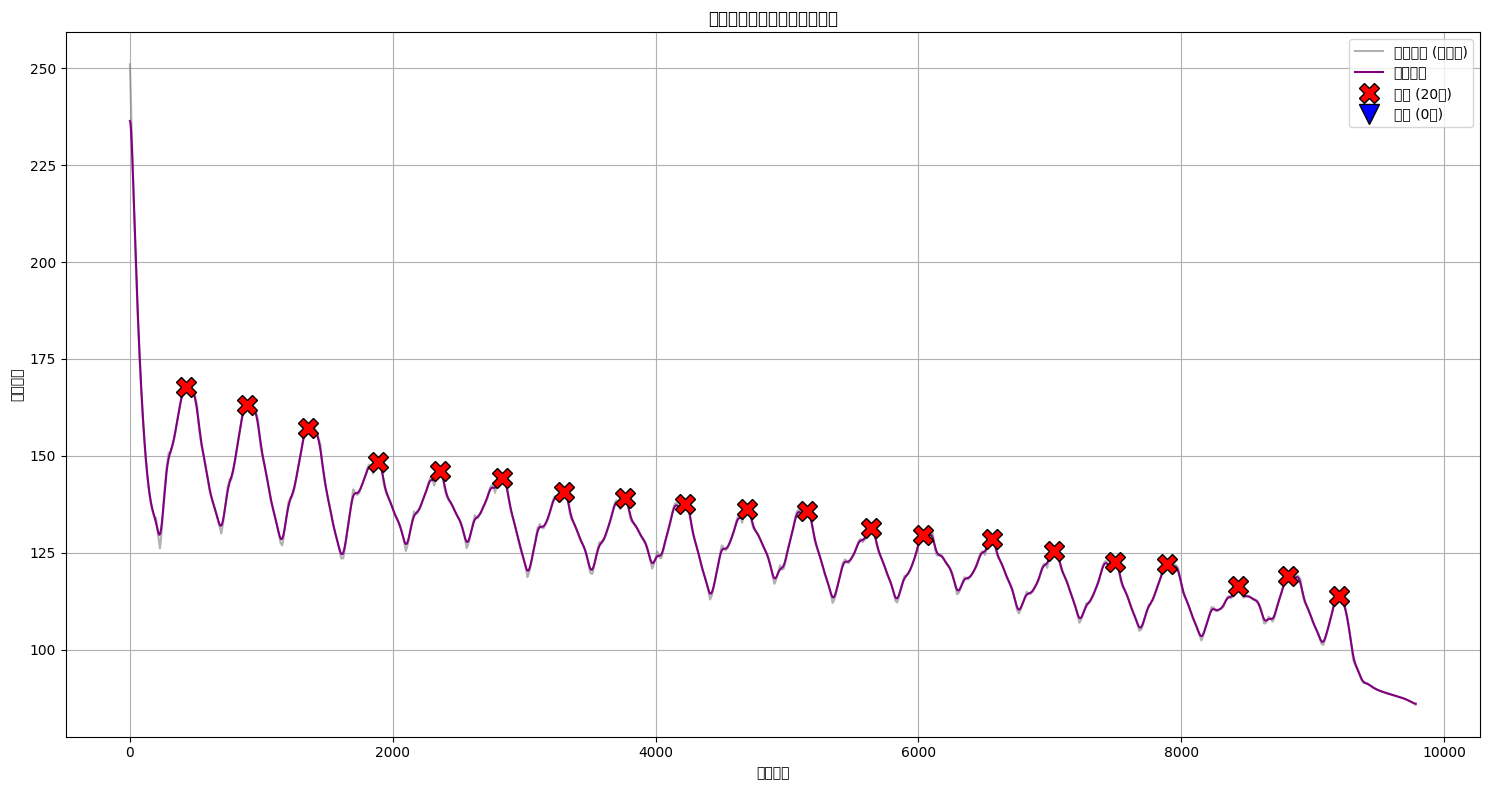


波峰波谷识别完成！


In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d # 用于平滑信号

def find_and_plot_peaks_troughs_no_time(signal,
                                         smoothing_sigma=3,
                                         peak_height=None, peak_distance=None,
                                         peak_prominence=None, peak_width=None,
                                         trough_height=None, trough_distance=None,
                                         trough_prominence=None, trough_width=None):
    """
    在一维信号中查找波峰和波谷，并在图中标注出来（不使用时间轴，X轴为索引）。

    参数:
    signal (array_like): 输入的一维信号数组。
    smoothing_sigma (float): 高斯平滑的标准差。值越大，平滑效果越强。
                             设置为 0 或 None 则不进行平滑。
    peak_height (float or tuple, optional): 识别波峰的最小高度 (或范围)。
    peak_distance (int, optional): 两个相邻波峰之间的最小水平距离 (采样点数)。
    peak_prominence (float, optional): 波峰的最小显著性。
    peak_width (float or tuple, optional): 波峰的最小宽度 (或范围)。
    trough_height (float or tuple, optional): 识别波谷的最小高度 (取负号后)。
    trough_distance (int, optional): 两个相邻波谷之间的最小水平距离 (采样点数)。
    trough_prominence (float, optional): 波谷的最小显著性 (取负号后)。
    trough_width (float or tuple, optional): 波谷的最小宽度 (取负号后)。
    """

    # X轴将是信号的索引
    x_axis_indices = np.arange(len(signal))

    # --- 1. 平滑信号 ---
    if smoothing_sigma is not None and smoothing_sigma > 0:
        smoothed_signal = gaussian_filter1d(signal, sigma=smoothing_sigma)
        print(f"信号已使用高斯滤波进行平滑，sigma={smoothing_sigma}")
    else:
        smoothed_signal = signal
        print("未对信号进行平滑处理。")

    # --- 2. 识别波峰 (Peaks) ---
    peak_params = {
        'height': peak_height,
        'distance': peak_distance,
        'prominence': peak_prominence,
        'width': peak_width
    }
    peak_params = {k: v for k, v in peak_params.items() if v is not None}
    
    peaks, _ = find_peaks(smoothed_signal, **peak_params)
    print(f"识别到 {len(peaks)} 个波峰。")

    # --- 3. 识别波谷 (Troughs) ---
    trough_params = {
        'height': trough_height,
        'distance': trough_distance,
        'prominence': trough_prominence,
        'width': trough_width
    }
    trough_params = {k: v for k, v in trough_params.items() if v is not None}
    
    troughs, _ = find_peaks(-smoothed_signal, **trough_params)
    print(f"识别到 {len(troughs)} 个波谷。")

    # --- 4. 绘图可视化 ---
    plt.figure(figsize=(15, 8))
    
    # 绘制原始信号
    plt.plot(x_axis_indices, signal, label='原始信号 (带噪声)', alpha=0.6, color='gray')
    
    # 绘制平滑后的信号
    if smoothing_sigma is not None and smoothing_sigma > 0:
        plt.plot(x_axis_indices, smoothed_signal, label='平滑信号', color='purple', linewidth=1.5)
    
    # 绘制波峰
    plt.plot(x_axis_indices[peaks], smoothed_signal[peaks], "X", markersize=15, 
             color='red', markeredgecolor='black', label=f'波峰 ({len(peaks)}个)')

    # 绘制波谷
    plt.plot(x_axis_indices[troughs], smoothed_signal[troughs], "v", markersize=15, 
             color='blue', markeredgecolor='black', label=f'波谷 ({len(troughs)}个)')

    plt.title('一维信号中的波峰与波谷识别')
    plt.xlabel('信号索引')
    plt.ylabel('信号幅值')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- 示例使用 ---
if __name__ == "__main__":
    # 假设你的信号数据是一个 Numpy 数组或列表
    # 你可以将你的实际信号数据替换这里的 `my_signal_data`
    
    np.random.seed(2025) # 为了结果可复现

    # 模拟一个包含噪声、周期性、尖峰和平台的一维信号
    # 这个信号有 2000 个数据点
    my_signal_data = data_smooth
    
    print("开始进行波峰波谷识别...")
    
    # 调用函数，设置识别参数
    # 这些参数需要根据你的实际信号特性进行调整
    find_and_plot_peaks_troughs_no_time(
        signal=my_signal_data,
        smoothing_sigma=15,  # 高斯平滑的 sigma 值，用于去除噪声，适当调整
        
        # 波峰识别参数
        peak_height=0,       # 波峰的最小高度为 0
        peak_distance=50,    # 波峰之间至少间隔 50 个采样点
        peak_prominence=2.0, # 波峰的显著性至少为 2.0
        peak_width=(5, None),# 波峰宽度至少为 5 个采样点，无上限
        
        # 波谷识别参数 (对取负后的信号而言)
        trough_height=-8,    # 波谷的“高度”阈值（对应于负信号的峰值），这里表示原信号波谷值低于-8
        trough_distance=50,  # 波谷之间至少间隔 50 个采样点
        trough_prominence=2.0, # 波谷的显著性
        trough_width=(5, None) # 波谷宽度至少为 5 个采样点
    )

    print("\n波峰波谷识别完成！")

去抖动采样点数: 10 (约 100 ms)


c:\Users\PC\anaconda3\envs\RL\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC\anaconda3\envs\RL\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC\anaconda3\envs\RL\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC\anaconda3\envs\RL\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC\anaconda3\envs\RL\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missin

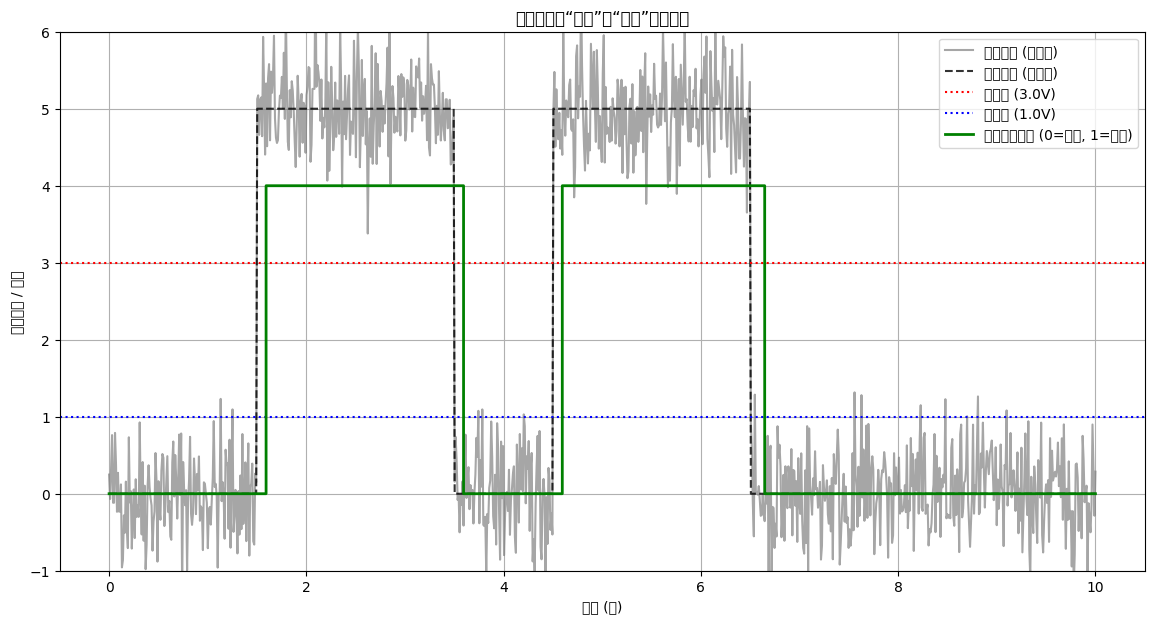


--- 状态转换点 ---
在时间 1.59s 处，状态从 弹起 切换到 按压
在时间 3.59s 处，状态从 按压 切换到 弹起
在时间 4.59s 处，状态从 弹起 切换到 按压
在时间 6.65s 处，状态从 按压 切换到 弹起


In [ ]:
import gymnasium as gym
from gymnasium.spaces import Box, Discrete,Tuple
import numpy as np
import pygame

# Define colors
WHITE = (255, 255, 255)
RED = (255, 0, 0)
GREEN = (0, 255, 0)
BLUE = (0, 0, 255)  # Color for the trajectory

class CustomEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 60}

    def __init__(self,render_mode=None):
        super().__init__()
        self.grid_size = 10
        self.pause = False
        self.domain_randomization = False
        self.render_mode = render_mode

        # Define two separate thresholds for obstacle handling
        self.distance_threshold_penalty = 4  # Penalty zone threshold (larger value)
        self.distance_threshold_collision = 1.5  # Collision threshold (smaller value)
        self.penalty_factor = 8  # Penalty scaling factor
        self.distance_reward_factor = 10
        self.smooth_action_penalty = 1
        self.steps = 0
        self.margin = 0.1
        


        self.current_distance = 0  # Current distance to goal, used for reward shaping
        self.max_steps = 40  # Set a maximum number of steps to prevent infinite loops
        # Action space (dx, dy)
        self.action_space = Box(low=-1, high=1, shape=(2,), dtype=np.float32)
        # Observation space (robot_x, robot_y, goal_x, goal_y)
        self.observation_shape = 2+2+2+1+1+1+2  # Robot position, hand position, velocity_hand,radius_hand, and distance to hand
        self.observation_space = Box(low=0, high=np.array([self.grid_size*2,self.grid_size, self.grid_size*2, self.grid_size,1,1 , (2**0.5)*self.grid_size,0.5*self.grid_size,0.5*self.grid_size,2*self.grid_size,self.grid_size]), 
                                     shape=(self.observation_shape,), dtype=np.float32)

        self.random = True
        # For rendering
        self.window = None
        self.clock = None
        self.cell_size = 50 # Pixels per grid unit
        self.trajectory_points = [] # New: List to store past robot positions
        self.dist_arm = 0


    def dist_point_to_segment_correct(self,P, A, B, eps=1e-12):
        P = np.asarray(P, dtype=float)
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        v = B - A
        w = P - A
        vv = np.dot(v, v)
        if vv <= eps:
            # A and B coincide: treat as point A
            C = A.copy()
            d = np.linalg.norm(P - A)
            t = 0.0
            case = 'endpoint_A'
        else:
            t = np.dot(w, v) / vv
            if t < 0.0:
                C = A
                d = np.linalg.norm(P - A)
                case = 'before_A'
            elif t > 1.0:
                C = B
                d = np.linalg.norm(P - B)
                case = 'after_B'
            else:
                C = A + t * v
                d = np.linalg.norm(P - C)
                case = 'on_segment'
        return float(d), C, float(t), case

    def _get_obs(self):
        
        return np.concatenate(([self.robot_position]+ [self.hand_position]+[self.last_action]+
                               [np.array([self.current_distance])]+
                               [np.array([min(self.robot_position[0],
                                              self.robot_position[1],
                                              self.grid_size-self.robot_position[0],
                                              self.grid_size-self.robot_position[1]) ])]+
                                              [np.array([self.dist_arm])]+
                                               [self.fixed_point]))

    def _get_info(self):
        return {
            "distance_to_hand": self.current_distance,
            "robot_position": self.robot_position,
            "hand_position": self.hand_position,
        }

    def reset(self, seed=None, options=None):

        super().reset()
        self.stride_hand = np.random.uniform(0.6, 1)  # Randomize stride length
        self.stride_robot = 1  # Randomize stride length
        self.distance_threshold_collision = np.random.uniform(2,3)  # Randomize collision threshold
        self.distance_threshold_penalty = np.random.uniform(3, 4)  # Randomize penalty threshold
        
        
        self.noise_obs_sigma = np.random.uniform(0, 0.1)  # Add some noise to observation to make it more realistic
        self.noise_action_sigma = np.random.uniform(0,0.1)  # Add some noise to action to make it more realistic
        
        
        
        self.robot_position = np.random.uniform(self.margin, [2*(self.grid_size-self.margin),self.grid_size-self.margin], size=2)
        self.hand_position = np.random.uniform(self.margin, [2*(self.grid_size-self.margin),self.grid_size-self.margin], size=2)
        # self.hand_position = np.clip(self.hand_position, self.margin, self.grid_size-self.margin)  # Ensure hand stays within grid bounds
        
        self.hand_move_mode = 'random' if np.random.rand() < 0.1 else 'towards_robot'  # Randomize hand movement mode
        
        self.current_distance = np.linalg.norm(self.robot_position - self.hand_position)
        self.pre_distance = self.current_distance
        self.last_action = np.zeros(2)
        self.steps = 0
        self.trajectory_points = [self.robot_position.copy()] # New: Reset trajectory and add initial position
        
        self.fixed_point = np.array([self.grid_size*random.uniform(0.2,1.8),self.grid_size])
        return self._get_obs(), self._get_info()

    def _reward(self,action):
        terminated = False
        truncated = False
        reward = 0  # Initialize reward
        done_reason = None  # Initialize done reason

        # action regulation penalty

        reward -= 0.5 * np.sum(np.square(action))  # Penalty for large actions

        self.dist_arm = self.dist_point_to_segment_correct(self.robot_position,self.hand_position, self.fixed_point)[0]
        if self.dist_arm < 1.5:
            reward -= 100
            terminated = True  # Truncate if arm is too short


        if np.any(self.robot_position <= self.margin) or (self.grid_size-self.robot_position[1] <=self.margin) or (2*self.grid_size-self.robot_position[0] <=self.margin):
            reward -= 400
            terminated = True  # Truncate if robot goes out of bounds
            done_reason = "out of bounds"

        # self.robot_position = np.clip(self.robot_position, self.margin, self.grid_size-self.margin)  # Ensure robot stays within grid bounds
        # boundary penalty

        reward -= self.smooth_action_penalty*np.linalg.norm(action-self.last_action)  # Penalty for smooth action
        self.last_action = action
        # Auxiliary Rewards -  distance to hand
        self.current_distance = np.linalg.norm(self.robot_position - self.hand_position)
        reward += (self.current_distance-self.pre_distance)*self.distance_reward_factor  # Reward shaping based on distance change
        self.pre_distance = self.current_distance

        # Obstacle handling with two thresholds
        if self.current_distance < self.distance_threshold_collision:
            reward -= 100
            terminated = True  # Terminate if too close to obstacles
            done_reason = "collision with obstacle"
        elif self.current_distance < self.distance_threshold_penalty:
            reward -= self.penalty_factor * (self.distance_threshold_penalty - self.current_distance)  # Penalty for being too close to obstacles

        
        
        reward+=  4  # Small reward for each step taken to encourage exploration
        if self.steps >= self.max_steps:
            reward += 50
            truncated = True  # Truncate if max steps reached
        return reward,terminated,truncated,done_reason

    def _get_hand_movement(self):

        if self.hand_move_mode == 'random':
            move_hand = np.random.uniform(-1, 1, size=2)  # Randomly move the hand position slightly
        elif self.hand_move_mode == 'towards_robot':
            dir_vector = self.robot_position - self.hand_position
            if np.linalg.norm(dir_vector) > 0:
                dir_vector /= np.linalg.norm(dir_vector)
            move_hand = dir_vector * self.stride_hand  # Move hand towards robot position
        
        return move_hand






    def step(self, action):




        self.robot_position += action * self.stride_robot  # Scale the action to control speed
        self.trajectory_points.append(self.robot_position.copy()) # New: Add current position to trajectory
        self.steps += 1
        

        reward,terminated,truncated,done_reason = self._reward(action)
        info = self._get_info()
        info['done_reason'] = done_reason
        observation = self._get_obs()
        if self.random:
            observation += np.random.normal(0, self.noise_obs_sigma, size=self.observation_shape)  # Add some noise to observation to make it more realistic

        return observation, reward, terminated, truncated, info

    def render(self, mode="human"):
 
        pygame.display.init()
        self.window = pygame.display.set_mode(
                (int(self.grid_size * self.cell_size), int(self.grid_size * self.cell_size))
            )
        pygame.display.set_caption("CustomEnv")
        if self.clock is None:
            self.clock = pygame.time.Clock()
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                import sys
                sys.exit() # Exit the program

            elif event.type == pygame.MOUSEBUTTONDOWN:
                mouse_x, mouse_y = event.pos
                self.hand_position = np.array([mouse_x/self.cell_size, mouse_y/self.cell_size])

            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_SPACE:  # 空格键切换暂停
                    self.pause = not self.pause


        canvas = pygame.Surface((self.grid_size * self.cell_size, self.grid_size * self.cell_size))
        canvas.fill(WHITE)
        virus_image = pygame.image.load("hand.png").convert_alpha()  # Load an image if needed, but not used here
        robot_image = pygame.transform.scale(virus_image, (int(self.cell_size * 2), int(self.cell_size * 2)))  # Scale the image
        # New: Draw the trajectory
        if len(self.trajectory_points) > 1:
            scaled_points = []
            for point in self.trajectory_points:
                scaled_points.append((int(point[0] * self.cell_size), int(point[1] * self.cell_size)))
            
            # Draw lines between consecutive points
            pygame.draw.lines(canvas, BLUE, False, scaled_points, 2) # Blue line, not closed, 2 pixels wide
            
            # Optionally, draw small circles at each point to emphasize
            for point_coord in scaled_points:
                pygame.draw.circle(canvas, BLUE, point_coord, 3) # Small blue circles

        # Draw robot
        pygame.draw.circle(
            canvas,
            RED,
            (int(self.robot_position[0] * self.cell_size), int(self.robot_position[1] * self.cell_size)),
            int(self.cell_size * 0.2)
        )
        # Draw obstacles

        canvas.blit(robot_image, (int((self.hand_position[0]-1) * self.cell_size), int((self.hand_position[1]-1) * self.cell_size+1)))
        pygame.draw.circle(canvas,
                            GREEN, 
                            (int((self.hand_position[0]) * self.cell_size), 
                            int((self.hand_position[1]) * self.cell_size+1)), 
        int(self.cell_size * 0.2)
        )

        self.window.blit(canvas, canvas.get_rect())
        pygame.event.pump()
        pygame.display.flip()
        self.clock.tick(self.metadata["render_fps"])
        time.sleep(0.5)

    def close(self):
        pygame.display.quit()
        pygame.quit()





In [2]:
import os
import json
from glob import glob

# ====== 配置 ======
# Labelme 标注 json 文件所在目录
labelme_json_dir = "../rl-project/data/label"
# 输出目录（YOLO 的 labels）
yolo_output_dir = "../rl-project/data/label_txt"
os.makedirs(yolo_output_dir, exist_ok=True)

# 类别映射（自己改成你数据集的类别）
# 比如 {"person": 0, "car": 1, "dog": 2}
class_mapping = {

    "robot": 0,

}

def convert_to_yolo(size, box):
    """把 (xmin, ymin, xmax, ymax) 转成 YOLO 格式"""
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]
    x = (box[0] + box[2]) / 2.0
    y = (box[1] + box[3]) / 2.0
    w = box[2] - box[0]
    h = box[3] - box[1]
    x = x * dw
    y = y * dh
    w = w * dw
    h = h * dh
    return (x, y, w, h)

# 遍历所有 json 文件
for json_file in glob(os.path.join(labelme_json_dir, "*.json")):
    print(f"处理文件: {json_file}")
    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    image_w = data["imageWidth"]
    image_h = data["imageHeight"]

    # 输出 txt 文件路径
    txt_file = os.path.join(
        yolo_output_dir,
        os.path.splitext(os.path.basename(json_file))[0] + ".txt"
    )

    with open(txt_file, "w", encoding="utf-8") as f_out:
        for shape in data["shapes"]:
            label = shape["label"]
            if label not in class_mapping:
                print(f"跳过未定义类别: {label}")
                continue

            points = shape["points"]
            # 取 polygon 的最小外接矩形
            xs = [p[0] for p in points]
            ys = [p[1] for p in points]
            xmin, xmax = min(xs), max(xs)
            ymin, ymax = min(ys), max(ys)

            # 转换 YOLO 格式
            x, y, w, h = convert_to_yolo((image_w, image_h), (xmin, ymin, xmax, ymax))
            class_id = class_mapping[label]

            f_out.write(f"{class_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

    print(f"转换完成: {json_file} → {txt_file}")


处理文件: ../rl-project/data/label\img0.json
转换完成: ../rl-project/data/label\img0.json → ../rl-project/data/label_txt\img0.txt
处理文件: ../rl-project/data/label\img1.json
转换完成: ../rl-project/data/label\img1.json → ../rl-project/data/label_txt\img1.txt
处理文件: ../rl-project/data/label\img10.json
转换完成: ../rl-project/data/label\img10.json → ../rl-project/data/label_txt\img10.txt
处理文件: ../rl-project/data/label\img11.json
转换完成: ../rl-project/data/label\img11.json → ../rl-project/data/label_txt\img11.txt
处理文件: ../rl-project/data/label\img12.json
转换完成: ../rl-project/data/label\img12.json → ../rl-project/data/label_txt\img12.txt
处理文件: ../rl-project/data/label\img13.json
转换完成: ../rl-project/data/label\img13.json → ../rl-project/data/label_txt\img13.txt
处理文件: ../rl-project/data/label\img14.json
转换完成: ../rl-project/data/label\img14.json → ../rl-project/data/label_txt\img14.txt
处理文件: ../rl-project/data/label\img15.json
转换完成: ../rl-project/data/label\img15.json → ../rl-project/data/label_txt\img15.txt
处理文件: 

In [3]:
import os
import shutil
import random


source = "../rl-project/data"  # 原始标签文件夹

list_img = os.listdir(os.path.join(source, "img"))
train_ratio = 0.8
random.shuffle(list_img)


num_total = len(list_img)
num_train = int(num_total * train_ratio)
num_val = num_total - num_train
train_files = list_img[:num_train]
val_files = list_img[num_train:]

# 输出目录
output_dir = "../rl-project/dataset"
os.makedirs(os.path.join(output_dir, "images/train"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "images/val"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "labels/train"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "labels/val"), exist_ok=True)

def copy_files(file_list, split):
    for img_file in file_list:
        base_name = os.path.splitext(img_file)[0]
        txt_file = base_name + ".txt"

        # 复制图片
        src_img_path = os.path.join(source, "img", img_file)
        dst_img_path = os.path.join(output_dir, f"images/{split}", img_file)
        shutil.copyfile(src_img_path, dst_img_path)

        # 复制标签
        src_txt_path = os.path.join(source, "label_txt", txt_file)
        dst_txt_path = os.path.join(output_dir, f"labels/{split}", txt_file)
        if os.path.exists(src_txt_path):
            shutil.copyfile(src_txt_path, dst_txt_path)
        else:
            print(f"警告：找不到标签文件 {txt_file} ，跳过。")

# 复制训练集
copy_files(train_files, "train")
# 复制验证集
copy_files(val_files, "val")

print(f"划分完成，总图片数: {num_total}")
print(f"训练集: {num_train} 张")
print(f"验证集: {num_val} 张")


划分完成，总图片数: 44
训练集: 35 张
验证集: 9 张
